In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
df = pd.read_csv("sentiment_data.csv", encoding="latin1")

# Remove unnecessary index column if present
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

In [5]:
print("\n--- DATASET INFO ---")
df.info()

print("\n--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- COLUMNS ---")
print(df.columns)


--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241145 entries, 0 to 241144
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Comment    240928 non-null  object
 1   Sentiment  241145 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.7+ MB

--- FIRST 5 ROWS ---
                                             Comment  Sentiment
0  lets FORGET not apple pay required "brand new ...          1
1  nz retailers DO NOT even "contactless credit c...          0
2  " hi "forever acknowledge CHANNEL  help lesson...          2
3  whenever "GO PLACE" doesnât take apple pay d...          0
4  aPPlE "apple" pay convenient secure easy use u...          2

--- COLUMNS ---
Index(['Comment', 'Sentiment'], dtype='object')


In [6]:
df["Comment"] = df["Comment"].fillna("").astype(str)

df["clean_text"] = df["Comment"].str.lower()

df["clean_text"] = df["clean_text"].str.translate(
    str.maketrans('', '', string.punctuation)
)

print("\n--- Cleaned Text ---")
print(df["clean_text"].head())


--- Cleaned Text ---
0    lets forget not apple pay required brand new i...
1    nz retailers do not even contactless credit ca...
2     hi forever acknowledge channel  help lessons ...
3    whenever go place doesnât take apple pay doe...
4    apple apple pay convenient secure easy use use...
Name: clean_text, dtype: object


In [7]:
df["Sentiment"] = df["Sentiment"].fillna("unknown").astype(str).str.lower()

sentiment_counts = df["Sentiment"].value_counts()

print("\n--- Sentiment Counts ---")
print(sentiment_counts)


--- Sentiment Counts ---
Sentiment
2    103059
1     82972
0     55114
Name: count, dtype: int64


In [27]:
positive_text = df[df["Sentiment"] == '1']["clean_text"]

words = " ".join(positive_text).split()

word_freq = pd.Series(words).value_counts()

print("\n--- Top Words (Positive Reviews) ---")
print(word_freq.head(10))


--- Top Words (Positive Reviews) ---
modi        47832
india        6412
like         4889
narendra     3985
bjp          3817
dont         3627
one          3475
congress     3454
people       3351
time         3065
Name: count, dtype: int64


In [9]:
stopwords = set([
    "the","is","in","and","to","of","a","it","that","this","for",
    "on","with","as","was","but","are","be","have","not"
])

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stopwords])

In [10]:
df["clean_text_no_stopwords"] = df["clean_text"].fillna("").astype(str).apply(remove_stopwords)

print("\n--- After Stopword Removal ---")
print(df["clean_text_no_stopwords"].head())


--- After Stopword Removal ---
0    lets forget apple pay required brand new iphon...
1    nz retailers do even contactless credit card m...
2    hi forever acknowledge channel help lessons id...
3    whenever go place doesnât take apple pay doe...
4    apple apple pay convenient secure easy use use...
Name: clean_text_no_stopwords, dtype: object


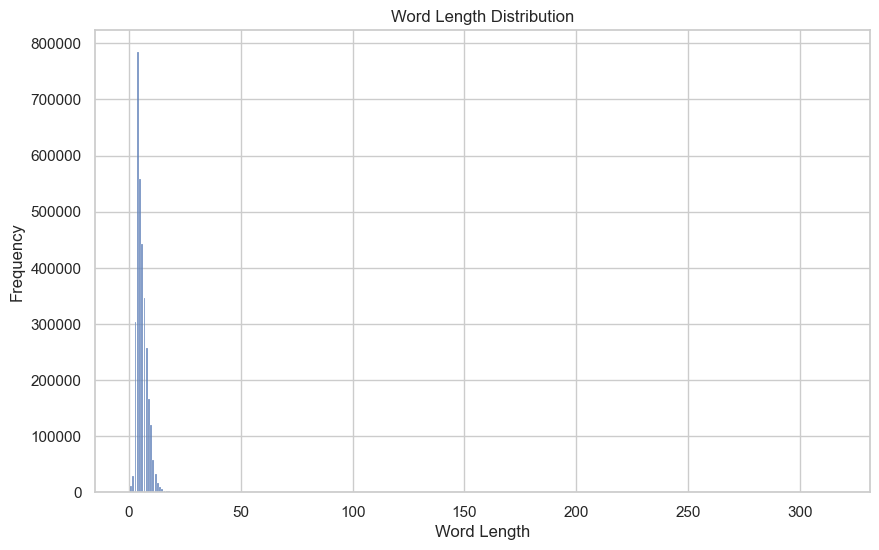

In [22]:
all_words = " ".join(df["clean_text_no_stopwords"]).split()

word_lengths = [len(word) for word in all_words]

plt.figure()

sns.histplot(
    word_lengths,
    discrete=True,
    shrink=0.8
)

plt.title("Word Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Frequency")

plt.show()

C:\Users\Arunangshu Dasgupta\AppData\Local\Temp\ipykernel_66608\1896890000.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


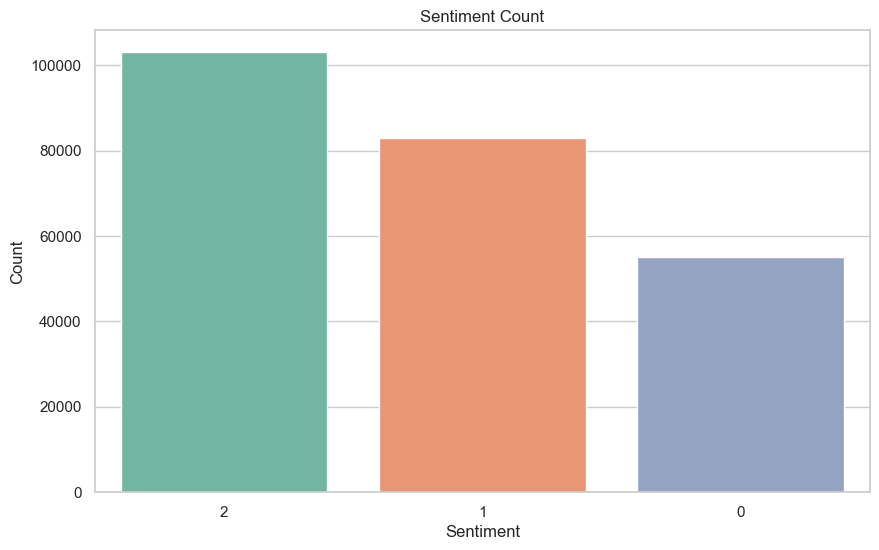

In [23]:
plt.figure()

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    palette="Set2" 
)

plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [28]:
negative_text = df[df["Sentiment"] == '0']["clean_text_no_stopwords"]

neg_words = " ".join(negative_text).split()

neg_freq = pd.Series(neg_words).value_counts()

print("\n--- Top Negative Keywords ---")
print(neg_freq.head(10))


--- Top Negative Keywords ---
modi        33900
india        6042
like         5020
people       4655
dont         3680
bjp          3495
congress     3353
one          3295
poor         2845
get          2808
Name: count, dtype: int64


In [26]:
print(df["Sentiment"].unique())

['1' '0' '2']


In [16]:
print("\n--- SUMMARY ---")

print("""
String processing improved sentiment analysis by:

1. Converting text to lowercase ensured uniformity and avoided duplicate words
   due to case differences.

2. Removing punctuation and stopwords reduced noise, allowing meaningful words
   to dominate frequency analysis.

3. Cleaned text enabled accurate identification of keywords influencing
   positive and negative sentiment.

Overall, preprocessing made the data structured and suitable for analysis.
""")


--- SUMMARY ---

String processing improved sentiment analysis by:

1. Converting text to lowercase ensured uniformity and avoided duplicate words
   due to case differences.

2. Removing punctuation and stopwords reduced noise, allowing meaningful words
   to dominate frequency analysis.

3. Cleaned text enabled accurate identification of keywords influencing
   positive and negative sentiment.

Overall, preprocessing made the data structured and suitable for analysis.

